# Library

In [ ]:
!pip install Sastrawi

In [ ]:
import pandas as pd
import string
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [ ]:
data_path = '/content/drive/MyDrive/UTY/Semester 7/Pemrosesan Teks /Clustering/data_labeled_mlbb.csv'

# Preprocessing

In [ ]:
df = pd.read_csv(data_path)

# Lowercase
df['clean'] = df['content'].str.lower()

# Remove Punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['clean'] = df['clean'].apply(remove_punctuation)

# Remove Repeating Characters
def remove_repeating_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

df['clean'] = df['clean'].apply(remove_repeating_chars)

# Remove Short Words
def remove_short_words(text, min_len=3):
    words = text.split()
    long_words = [word for word in words if len(word) >= min_len]
    return ' '.join(long_words)

df['clean'] = df['clean'].apply(remove_short_words)

df.head()

,userName,content,label,clean
0,JIDAPOWER JIDA,malas nak cakap lagi dh enemy dh la pro tim dh...,negative,malas nak cakap lagi enemy pro tim noob lagi p...
1,Galih Najid,game ytim,negative,game ytim
2,Muhammad Nibras,bagus saya suka tapi berikan saya ws lebih ban...,positive,bagus saya suka tapi berikan saya lebih banyak...
3,Ken Chuu,udah semenjak ganti season baru ini . makin ng...,negative,udah semenjak ganti season baru ini makin ngac...
4,IND khadafi,game nya udah bagus tapi. tolong perbaikilah m...,neutral,game nya udah bagus tapi tolong perbaikilah mu...


## Replace Slang Words

In [ ]:
slang_dict = {
      'bagu':'bagus',
      'bgt':'banget',
      'gak':'tidak',
      'gk':'tidak',
      'gw':'aku',
      'trus':'terus',
      'monton':'moonton',
      'montoon':'moonton',
      'maen':'main',
      'leg':'lag',
      'ngelag':'lag',
      'ngeleg':'lag',
      'klo':'kalau',
      'tim':'team',
      'ga':'tidak',
      'lu':'kamu',
      'gem':'game',
      'gua':'aku',
      'saya':'aku',
      'g':'tidak',
      'kalo':'kalau',
      'gin':'game',
      'yg':'yang',
      'ngelek':'lag',
      'sering lag':'lag',
      'kayak':'seperti',
      'kaya':'seperti',
      'geme':'game',
      'i':'aku',
      'ny':'nya',
      'gamenya':'game',
      'x':'kali',
      'dark':'gelap',
      'bener':'benar',
      'benerin':'rusak',
      'dibenerin':'rusak',
      'beneran':'serius',
      'gabener':'salah',
      'benerr':'benar',
      'benerlah':'benar',
      'bbenerin':'rusak',
      'benere':'benar',
      'benerlaa':'benar',
      'ngasih':'beri',
      'udh':'sudah',
      'ni':'ini',
      'karna':'karena',
      'min':'minimal',
      'burik':'buruk',
      'sampe':'sampai',
      'pake':'pakai',
      'drak':'gelap',
      'emang':'memang',
      'dikit':'sedikit',
      'dikitlh':'sedikit',
      'cuman':'hanya',
      'dah':'sudah',
      'berik':'beri',
      'ajha':'aja',
      'kek':'seperti',
      'lapor':'report',
      'laporin':'report',
      'ngelaporin':'report',
      'reportnya':'report',
      'direport':'report',
      'ngreport':'report',
      'cobain':'coba',
      'coban':'coba',
      'temen':'teman',
      'temenya':'teman',
      'temanteman':'teman',
      'temantemanku':'teman',
      'jagoteman':'jago',
      'doang':'hanya',
      'drag':'gelap',
      'system':'sistem',
      'dpt':'dapat',
      'tetep':'tetap',
      'stress':'stres',
      'nggak':'tidak',
      'skil':'skill',
      'skillnya':'skill',
      'skills':'skill',
      'bosok':'buruk',
      'bobrok':'buruk',
      'anjlok':'buruk',
      'toksik':'buruk',
      'kalok':'kalau',
      'ok':'oke',
      'okey':'oke',
      'gue':'aku',
      'baguss':'bagus',
      'anda':'kamu',
      'terimakasi':'terimakasih',
      'terima':'terimakasih',
      'makasihh':'terimakasih',
      'trjmakasih':'terimakasih',
      'trimakasih':'terimakasih',
      'makasih':'terimakasih',
      'tpi':'tapi',
      'aj':'aja',
      'jdi':'jadi',
      'ampas':'buruk',
      'woi':'buruk',
      'tp':'tapi',
      'matchmakingnya':'matchmaking',
      'bet':'banget',
      'ytim':'yatim',
      'sangatt':'sangat',
      'inisangat':'sangat'
}

def replace_slang(text):
    words = text.split()
    new_words = [slang_dict.get(word, word) for word in words]
    return ' '.join(new_words)

df['clean'] = df['clean'].apply(replace_slang)

df.head()

,userName,content,label,clean
0,JIDAPOWER JIDA,malas nak cakap lagi dh enemy dh la pro tim dh...,negative,malas nak cakap lagi enemy pro team noob lagi ...
1,Galih Najid,game ytim,negative,game yatim
2,Muhammad Nibras,bagus saya suka tapi berikan saya ws lebih ban...,positive,bagus aku suka tapi berikan aku lebih banyak lagi
3,Ken Chuu,udah semenjak ganti season baru ini . makin ng...,negative,udah semenjak ganti season baru ini makin ngac...
4,IND khadafi,game nya udah bagus tapi. tolong perbaikilah m...,neutral,game nya udah bagus tapi tolong perbaikilah mu...


## Remove Stopwords

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set([
    'yang', 'nya', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah', 'itu', 'aja', 'tapi', 'sih', 'dapet', 'tiap', 'saat', 'tapi', 'kasih', 'jaring',
    'pas', 'mulu', 'dulu', 'ini', 'saya', 'kami', 'kita', 'anda', 'mereka', 'atau', 'juga', 'tidak', 'eh', 'nyeselin', 'yah', 'ya', 'nah', 'kok', 'lagi', 'udah',
    'jadi', 'karena', 'agar', 'supaya', 'moonton', 'sebagai', 'oleh', 'terhadap', 'tentang', 'bahwa', 'hanya', 'saja', 'masih', 'telah', 'akan', 'bisa', 'dapat',
    'harus', 'boleh', 'mau', 'ingin', 'perlu', 'nya','game', 'hp', 'gamenya', 'tara', 'ml', 'hok', 'ada', 'aku', 'main', 'hero', 'rank', 'team', 'kalau', 'apa',
    'player', 'terus', 'sama', 'lah', 'nge', 'matchmaking', 'match', 'malah', 'download', 'orang', 'padahal', 'making', 'tau', 'plis', 'tencent', 'malah', 'buat',
    'udah', 'seperti', 'bikin', 'sering', 'kali', 'tiap', 'tiba', 'sekali', 'solo', 'data', 'kok', 'ku', 'saat', 'honor', 'of', 'kings', 'legend', 'mobile', 'dong',
    'belah', 'hari', 'tuh', 'kan', 'in', 'mlbb', 'soal', 'pun', 'login', 'waktu', 'kata', 'moba', 'mode', 'pakai', 'the', 'kalian', 'lane', 'sistem', 'nih', 'war',
    'simpan', 'fitur', 'ketika', 'awal', 'pick', 'cara', 'ama', 'gilir', 'nama', 'map', 'to', 'masak', 'gameplay', 'beli', 'loh', 'kesini', 'sini', 'apalagi', 'turut',
    'deh', 'memang', 'kembali', 'baca', 'bakal', 'temu', 'daripada', 'rasa', 'is', 'a', 'si', 's', 'jam', 'tahun', 'liat', 'depan', 'la', 'sangat', 'kamu'
])

def stem_text(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    stemmed_words = [stemmer.stem(word) for word in filtered_words]
    return ' '.join(stemmed_words)

df['clean'] = df['clean'].apply(stem_text)

df.head()

,userName,content,label,clean
0,JIDAPOWER JIDA,malas nak cakap lagi dh enemy dh la pro tim dh...,negative,malas nak cakap enemy pro noob paling malas re...
1,Galih Najid,game ytim,negative,yatim
2,Muhammad Nibras,bagus saya suka tapi berikan saya ws lebih ban...,positive,bagus suka ikan lebih banyak
3,Ken Chuu,udah semenjak ganti season baru ini . makin ng...,negative,semenjak ganti season baru makin ngaco matchin...
4,IND khadafi,game nya udah bagus tapi. tolong perbaikilah m...,neutral,bagus tolong baik muntun renk computer musuh s...


# Vectorizer

## Tf-Idf

In [ ]:
df_tf = df.copy()

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_tf['clean'])
feature_names = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)


## Bag of Words

In [ ]:
df_bow = df.copy()

In [ ]:
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(df_bow['clean'])
feature_names_bow = bow_vectorizer.get_feature_names_out()
df_bow_vectorized = pd.DataFrame(bow_matrix.toarray(), columns=feature_names_bow)

#  Split Data

In [ ]:
X_tf = df_tfidf
y_tf = df_tf['label']

X_bow = df_bow_vectorized
y_bow = df_bow['label']

X_tf_train, X_tf_test, y_tf_train, y_tf_test = train_test_split(X_tf, y_tf, test_size = 0.2, random_state = 42)

X_bow_train, X_bow_test, y_bow_train, y_bow_test = train_test_split(X_bow, y_bow, test_size = 0.2, random_state = 42)

# Experiments

## Clustering with K-Means

### K-Means - Tf-Idf

In [ ]:
kmeans_tf = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_tf['kmeans_cluster'] = kmeans_tf.fit_predict(X_tf)

display(df_tf.head())

,userName,content,label,clean,kmeans_cluster
0,JIDAPOWER JIDA,malas nak cakap lagi dh enemy dh la pro tim dh...,negative,malas nak cakap enemy pro noob paling malas re...,0
1,Galih Najid,game ytim,negative,yatim,0
2,Muhammad Nibras,bagus saya suka tapi berikan saya ws lebih ban...,positive,bagus suka ikan lebih banyak,0
3,Ken Chuu,udah semenjak ganti season baru ini . makin ng...,negative,semenjak ganti season baru makin ngaco matchin...,0
4,IND khadafi,game nya udah bagus tapi. tolong perbaikilah m...,neutral,bagus tolong baik muntun renk computer musuh s...,2


### K-Means - Bag of Words

In [ ]:
kmeans_bow = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_bow['kmeans_cluster'] = kmeans_bow.fit_predict(X_bow)

display(df_bow.head())

,userName,content,label,clean,kmeans_cluster
0,JIDAPOWER JIDA,malas nak cakap lagi dh enemy dh la pro tim dh...,negative,malas nak cakap enemy pro noob paling malas re...,1
1,Galih Najid,game ytim,negative,yatim,1
2,Muhammad Nibras,bagus saya suka tapi berikan saya ws lebih ban...,positive,bagus suka ikan lebih banyak,1
3,Ken Chuu,udah semenjak ganti season baru ini . makin ng...,negative,semenjak ganti season baru makin ngaco matchin...,1
4,IND khadafi,game nya udah bagus tapi. tolong perbaikilah m...,neutral,bagus tolong baik muntun renk computer musuh s...,1


## Filter Data by Sentiment


In [ ]:
df_tf_positive = df_tf[df_tf['label'] == 'positive']
df_tf_negative = df_tf[df_tf['label'] == 'negative']

df_bow_positive = df_bow[df_bow['label'] == 'positive']
df_bow_negative = df_bow[df_bow['label'] == 'negative']

### Visualize Cluster Distribution by Sentiment


/tmp/ipython-input-1630070719.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='kmeans_cluster', data=df_tf_positive, palette='viridis')
/tmp/ipython-input-1630070719.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='kmeans_cluster', data=df_tf_negative, palette='viridis')
/tmp/ipython-input-1630070719.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='kmeans_cluster', data=df_bow_positive, palette='magma')
/tmp/ipython-input-1630070719.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and 

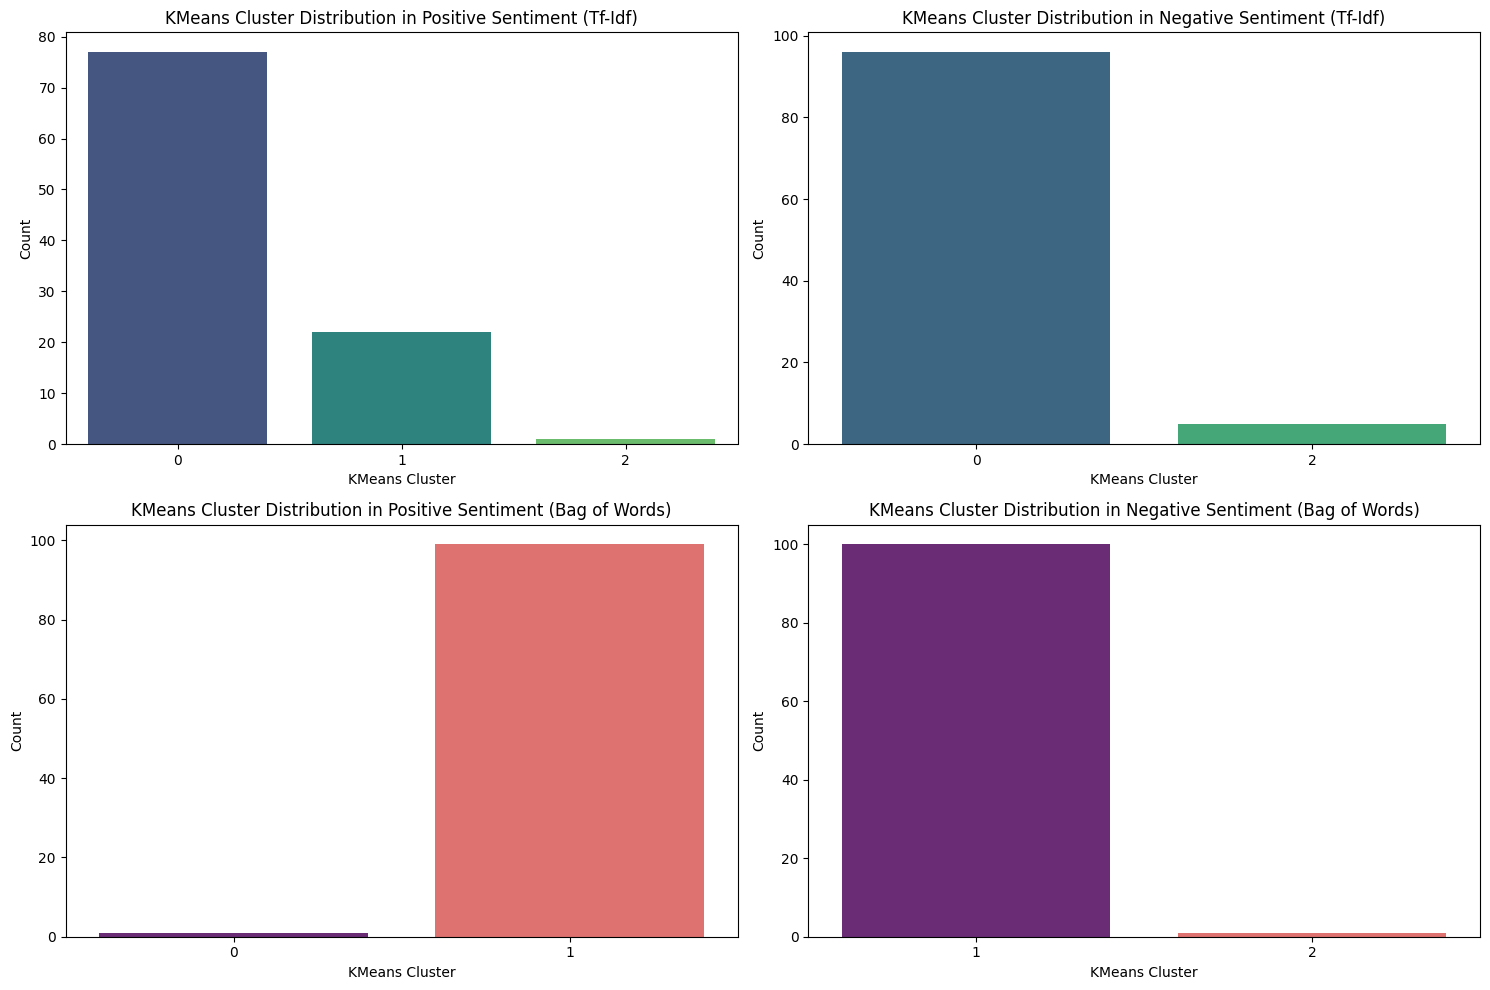

In [ ]:
plt.figure(figsize=(15, 10))

# Countplot for df_tf_positive
plt.subplot(2, 2, 1)
sns.countplot(x='kmeans_cluster', data=df_tf_positive, palette='viridis')
plt.title('KMeans Cluster Distribution in Positive Sentiment (Tf-Idf)')
plt.xlabel('KMeans Cluster')
plt.ylabel('Count')

# Countplot for df_tf_negative
plt.subplot(2, 2, 2)
sns.countplot(x='kmeans_cluster', data=df_tf_negative, palette='viridis')
plt.title('KMeans Cluster Distribution in Negative Sentiment (Tf-Idf)')
plt.xlabel('KMeans Cluster')
plt.ylabel('Count')

# Countplot for df_bow_positive
plt.subplot(2, 2, 3)
sns.countplot(x='kmeans_cluster', data=df_bow_positive, palette='magma')
plt.title('KMeans Cluster Distribution in Positive Sentiment (Bag of Words)')
plt.xlabel('KMeans Cluster')
plt.ylabel('Count')

# Countplot for df_bow_negative
plt.subplot(2, 2, 4)
sns.countplot(x='kmeans_cluster', data=df_bow_negative, palette='magma')
plt.title('KMeans Cluster Distribution in Negative Sentiment (Bag of Words)')
plt.xlabel('KMeans Cluster')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Most Frequent Words per Cluster

### Tf-Idf  -  Positive Sentiment

Top 10 most frequent words per cluster (Tf-Idf - Positive Sentiment):

--- Cluster 0 (Positive Tf-Idf) ---


/tmp/ipython-input-171055305.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='viridis')


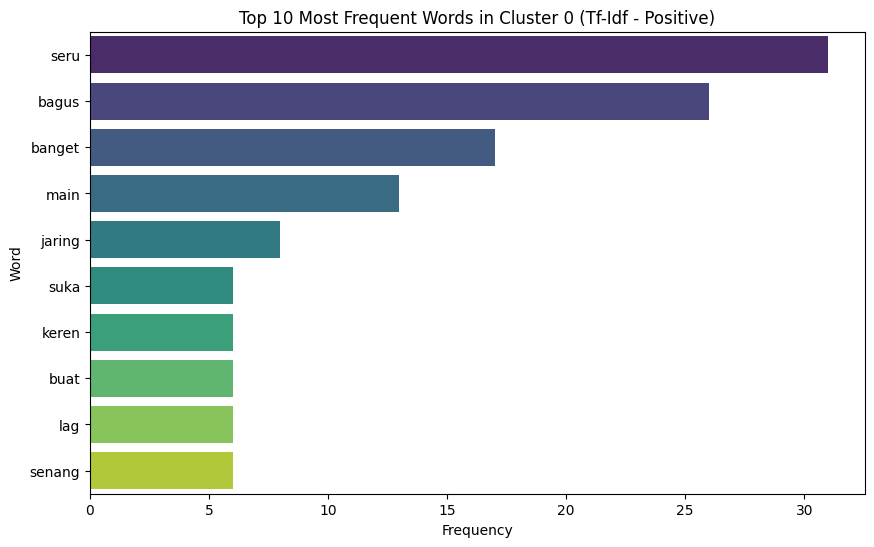


--- Cluster 1 (Positive Tf-Idf) ---


/tmp/ipython-input-171055305.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='viridis')


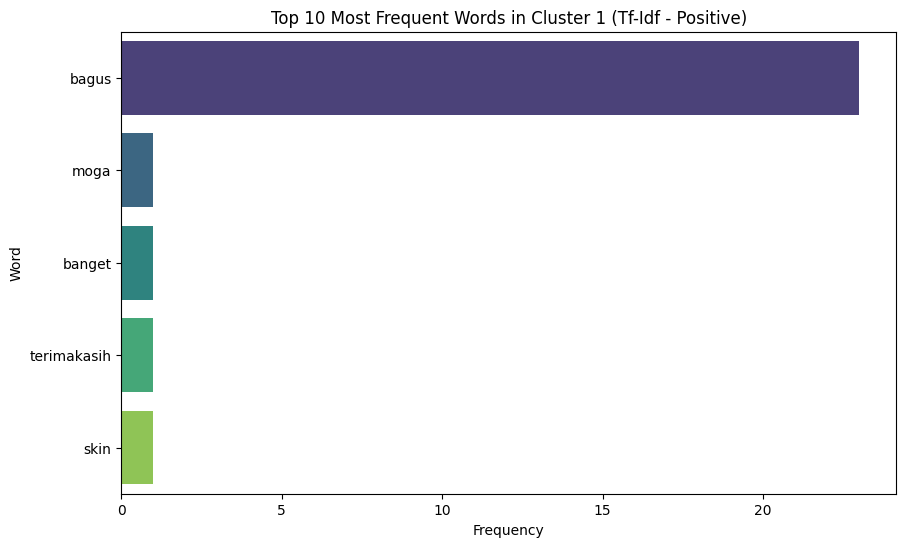


--- Cluster 2 (Positive Tf-Idf) ---


/tmp/ipython-input-171055305.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='viridis')


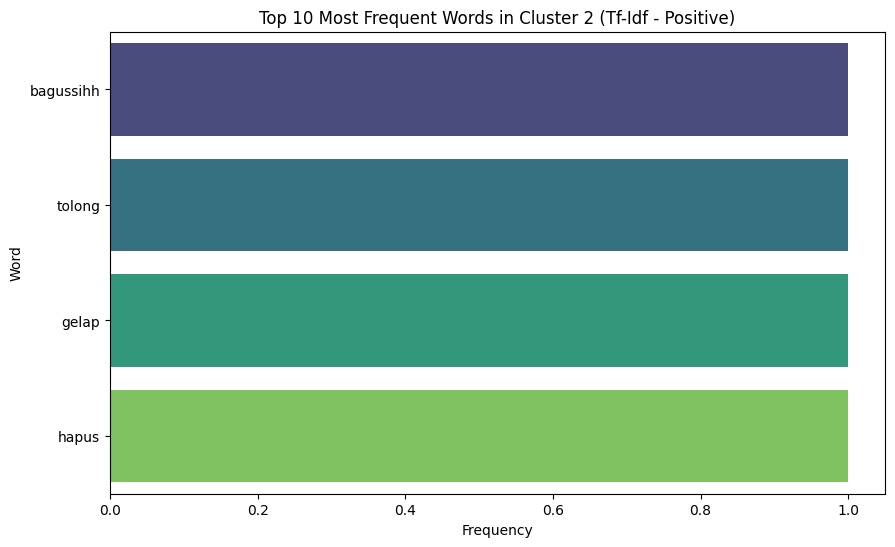

In [ ]:
print("Top 10 most frequent words per cluster (Tf-Idf - Positive Sentiment):")
for cluster_id in sorted(df_tf_positive['kmeans_cluster'].unique()):
    print(f"\n--- Cluster {cluster_id} (Positive Tf-Idf) ---")
    cluster_texts = df_tf_positive[df_tf_positive['kmeans_cluster'] == cluster_id]['clean']

    if not cluster_texts.empty:
        vectorizer = CountVectorizer()
        X = vectorizer.fit_transform(cluster_texts)
        word_counts = X.sum(axis=0)
        words_freq = [(word, word_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

        top_10_words = words_freq[:10]
        words = [word for word, count in top_10_words]
        counts = [count for word, count in top_10_words]

        df_plot = pd.DataFrame({'Word': words, 'Count': counts})

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Count', y='Word', data=df_plot, palette='viridis')
        plt.title(f'Top 10 Most Frequent Words in Cluster {cluster_id} (Tf-Idf - Positive)')
        plt.xlabel('Frequency')
        plt.ylabel('Word')
        plt.show()
    else:
        print("No data for this cluster.")

### Tf-Idf  -  Negative Sentiment

Top 10 most frequent words per cluster (Tf-Idf - Negative Sentiment):

--- Cluster 0 (Negative Tf-Idf) ---


/tmp/ipython-input-1494675779.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='plasma')


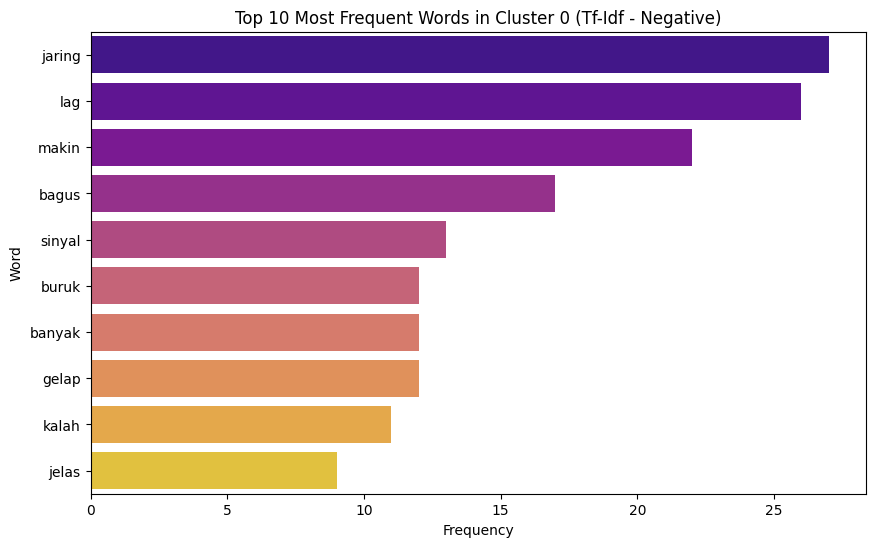


--- Cluster 2 (Negative Tf-Idf) ---


/tmp/ipython-input-1494675779.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='plasma')


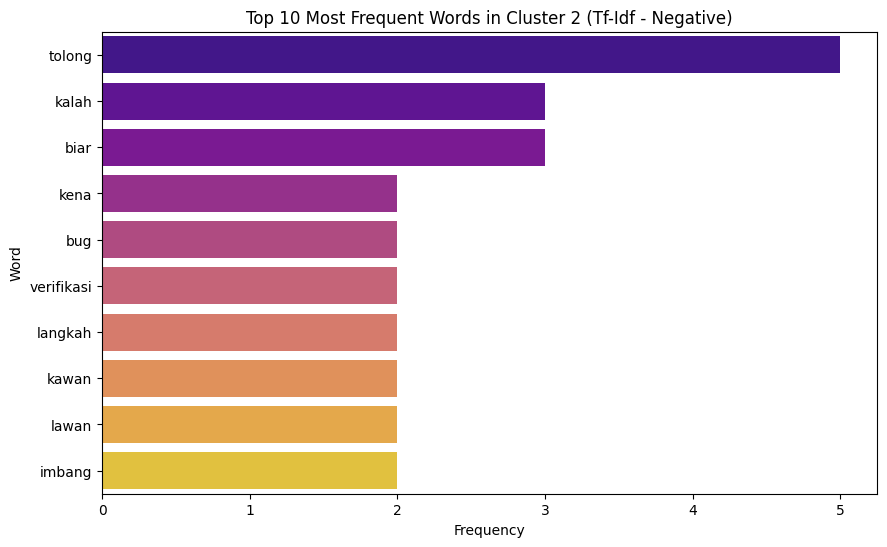

In [ ]:
print("Top 10 most frequent words per cluster (Tf-Idf - Negative Sentiment):")
for cluster_id in sorted(df_tf_negative['kmeans_cluster'].unique()):
    print(f"\n--- Cluster {cluster_id} (Negative Tf-Idf) ---")
    cluster_texts = df_tf_negative[df_tf_negative['kmeans_cluster'] == cluster_id]['clean']

    if not cluster_texts.empty:
        vectorizer = CountVectorizer()
        X = vectorizer.fit_transform(cluster_texts)
        word_counts = X.sum(axis=0)
        words_freq = [(word, word_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

        top_10_words = words_freq[:10]
        words = [word for word, count in top_10_words]
        counts = [count for word, count in top_10_words]

        df_plot = pd.DataFrame({'Word': words, 'Count': counts})

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Count', y='Word', data=df_plot, palette='plasma')
        plt.title(f'Top 10 Most Frequent Words in Cluster {cluster_id} (Tf-Idf - Negative)')
        plt.xlabel('Frequency')
        plt.ylabel('Word')
        plt.show()
    else:
        print("No data for this cluster.")

### Bag of Words  -  Positive Sentiment

Top 10 most frequent words per cluster (Bag of Words - Positive Sentiment):

--- Cluster 0 (Positive Bag of Words) ---


/tmp/ipython-input-1130843329.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='magma')


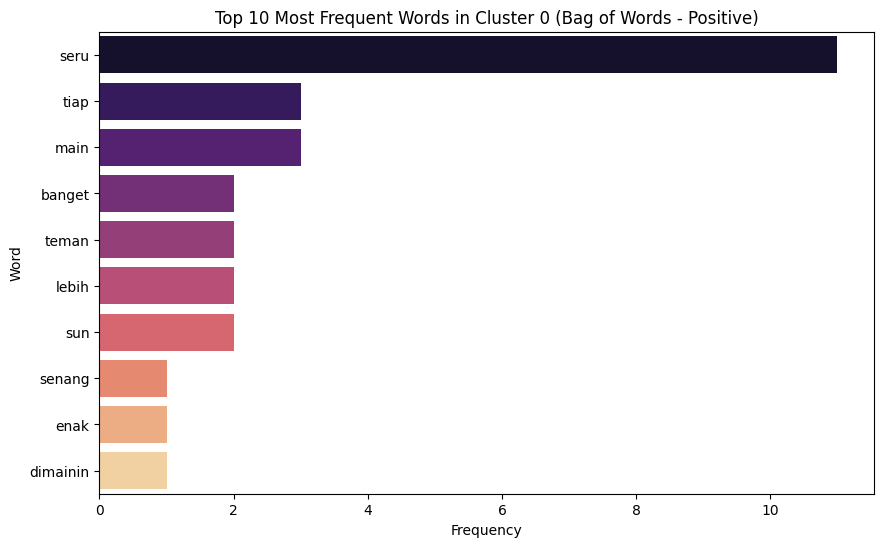


--- Cluster 1 (Positive Bag of Words) ---


/tmp/ipython-input-1130843329.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='magma')


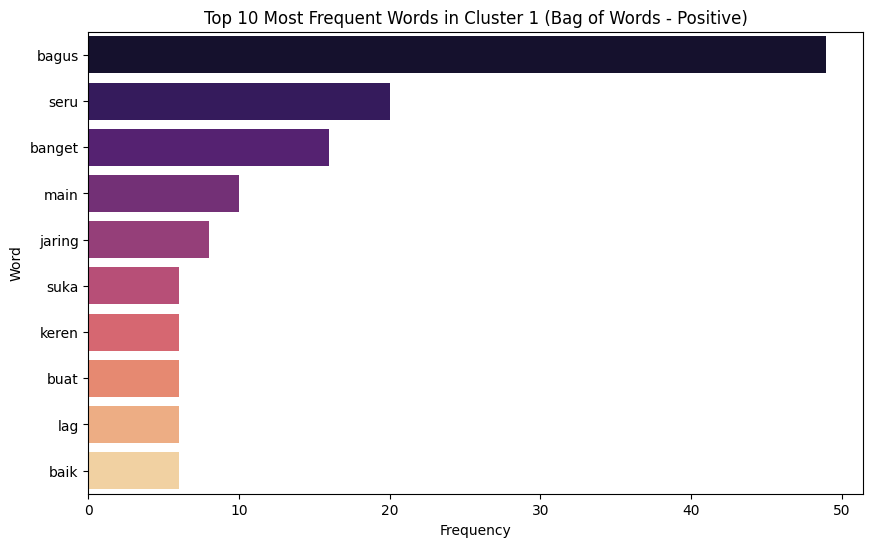

In [ ]:
print("Top 10 most frequent words per cluster (Bag of Words - Positive Sentiment):")
for cluster_id in sorted(df_bow_positive['kmeans_cluster'].unique()):
    print(f"\n--- Cluster {cluster_id} (Positive Bag of Words) ---")
    cluster_texts = df_bow_positive[df_bow_positive['kmeans_cluster'] == cluster_id]['clean']

    if not cluster_texts.empty:
        vectorizer = CountVectorizer()
        X = vectorizer.fit_transform(cluster_texts)
        word_counts = X.sum(axis=0)
        words_freq = [(word, word_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

        top_10_words = words_freq[:10]
        words = [word for word, count in top_10_words]
        counts = [count for word, count in top_10_words]

        df_plot = pd.DataFrame({'Word': words, 'Count': counts})

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Count', y='Word', data=df_plot, palette='magma')
        plt.title(f'Top 10 Most Frequent Words in Cluster {cluster_id} (Bag of Words - Positive)')
        plt.xlabel('Frequency')
        plt.ylabel('Word')
        plt.show()
    else:
        print("No data for this cluster.")

### Bag of Words  -  Negative Sentiment

Top 10 most frequent words per cluster (Bag of Words - Negative Sentiment):

--- Cluster 1 (Negative Bag of Words) ---


/tmp/ipython-input-1965535579.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='cividis')


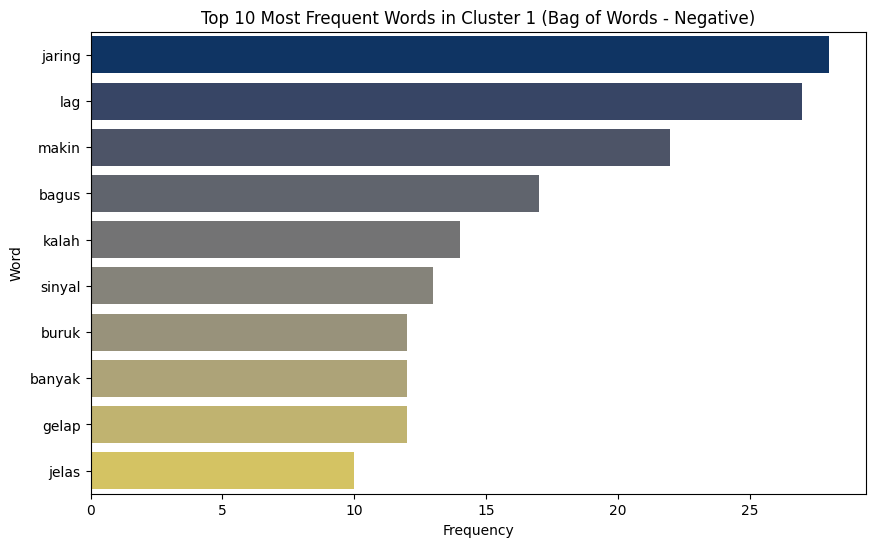


--- Cluster 2 (Negative Bag of Words) ---


/tmp/ipython-input-1965535579.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_plot, palette='cividis')


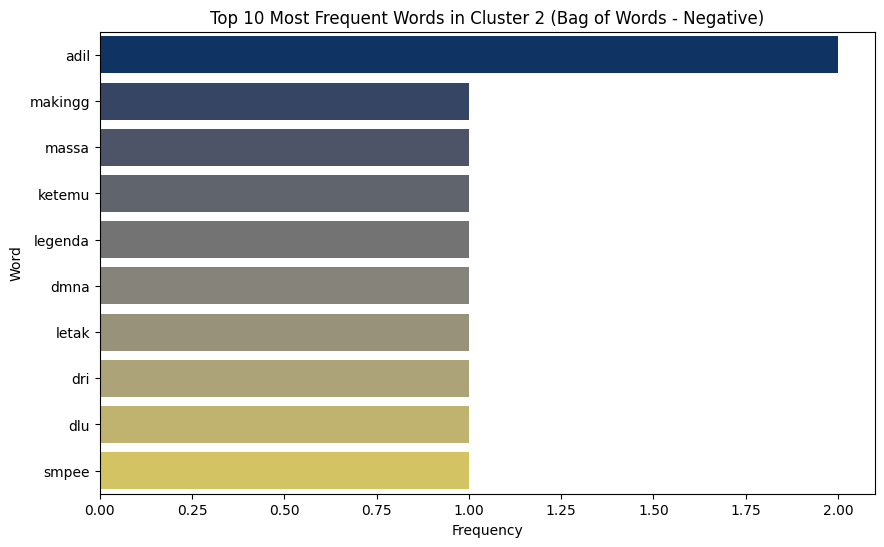

In [ ]:
print("Top 10 most frequent words per cluster (Bag of Words - Negative Sentiment):")
for cluster_id in sorted(df_bow_negative['kmeans_cluster'].unique()):
    print(f"\n--- Cluster {cluster_id} (Negative Bag of Words) ---")
    cluster_texts = df_bow_negative[df_bow_negative['kmeans_cluster'] == cluster_id]['clean']

    if not cluster_texts.empty:
        vectorizer = CountVectorizer()
        X = vectorizer.fit_transform(cluster_texts)
        word_counts = X.sum(axis=0)
        words_freq = [(word, word_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

        top_10_words = words_freq[:10]
        words = [word for word, count in top_10_words]
        counts = [count for word, count in top_10_words]

        df_plot = pd.DataFrame({'Word': words, 'Count': counts})

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Count', y='Word', data=df_plot, palette='cividis')
        plt.title(f'Top 10 Most Frequent Words in Cluster {cluster_id} (Bag of Words - Negative)')
        plt.xlabel('Frequency')
        plt.ylabel('Word')
        plt.show()
    else:
        print("No data for this cluster.")